In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import xgboost as xgb
from xgboost import plot_importance
import joblib

In [2]:
TUNNEL_FILE = r"C:\Users\magan\Documents\nfstream_test\ICMP_Tunneling_labelled_DATASET.csv"
FLOOD_FILE = r"C:\Users\magan\Downloads\HPE Project\Week 11\icmp_dataset_final.csv"

df_t = pd.read_csv(TUNNEL_FILE)
df_f = pd.read_csv(FLOOD_FILE)

C:\Users\magan\AppData\Local\Temp\ipykernel_17528\2887490444.py:4: DtypeWarning: Columns (0: server_fingerprint) have mixed types. Specify dtype option on import or set low_memory=False.
  df_t = pd.read_csv(TUNNEL_FILE)


In [3]:
df_t.Label.value_counts()

Label
Attack    82354
Benign     5402
Name: count, dtype: int64

In [ ]:
df_t['Label'] = df_t['Label'].map({'Attack': 'ICMP_Tunnel', 'Benign': 'Benign'})
df_f['Label'] = df_f['Label'].map({'ICMP_FLOOD': 'ICMP_Flood', 'BENIGN': 'Benign'})

df_t.columns = [c.strip() for c in df_t.columns]
df_f.columns = [c.strip() for c in df_f.columns]

df = pd.concat([df_t, df_f], ignore_index=True)

print(f"Combined Dataset Shape: {df.shape}")
print("\nClass Distribution:")
print(df['Label'].value_counts())

Combined Dataset Shape: (576644, 118)

Class Distribution:
Label
ICMP_Flood     268888
Benign         225402
ICMP_Tunnel     82354
Name: count, dtype: int64


In [5]:
duplicates_df = df[df.duplicated(keep=False)]
duplicates_df = duplicates_df.sort_values(by=['bidirectional_duration_ms', 'bidirectional_bytes'])

print(f"Total rows involved in duplication: {len(duplicates_df)}")
duplicates_df.head(10) 

Total rows involved in duplication: 0


,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,...,Fwd Pkts/s,Bwd Pkts/s,Down/Up Ratio,Pkt Len Var,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd IAT Tot,Bwd IAT Tot,Label,Unnamed: 0


In [20]:
metadata_cols = [
    "id", "expiration_id", "src_ip", "src_mac", "src_oui", "src_port",
    "dst_ip", "dst_mac", "dst_oui", "dst_port", "vlan_id", "tunnel_id",
    "application_name", "application_category_name", "application_is_guessed", 
    "application_confidence", "requested_server_name", "client_fingerprint",
    "server_fingerprint", "user_agent", "content_type", "Unnamed: 0","bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",   "src2dst_first_seen_ms", "src2dst_last_seen_ms","protocol", "ip_version"
]

df.drop(columns=metadata_cols, inplace=True, errors="ignore")

In [21]:
numeric_df = df.select_dtypes(include=[np.number])

# 1. Completely Zero Columns
all_zero = numeric_df.columns[(numeric_df == 0).all()].tolist()

# 2. Zero Variance (Constant values)
zero_var = numeric_df.columns[numeric_df.std() == 0].tolist()

# 3. Near-Zero Variance (Highly sparse features)
near_zero_var = numeric_df.columns[numeric_df.std() < 0.01].tolist()

drop_candidates = list(set(all_zero + zero_var + near_zero_var))

print(f"Identified {len(drop_candidates)} features with zero/near-zero variance.")
print(drop_candidates)

df.drop(columns=drop_candidates, inplace=True, errors='ignore')
print(f"\nFinal Feature Count: {len(df.columns) - 1}") # -1 for Label

Identified 0 features with zero/near-zero variance.
[]

Final Feature Count: 71


In [22]:
X = df.drop(columns=["Label"])
le = LabelEncoder()
y = le.fit_transform(df["Label"])

classes_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print("Encoded Classes:", classes_dict)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

Encoded Classes: {'Benign': np.int64(0), 'ICMP_Flood': np.int64(1), 'ICMP_Tunnel': np.int64(2)}
Train size: 461,315  |  Test size: 115,329


In [23]:
model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 5, 
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = "multi:softprob",
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1
)

print("Training model...")
model.fit(X_train, y_train, sample_weight=sample_weights, 
          eval_set=[(X_test, y_test)], verbose=25)

Training model...
[0]	validation_0-mlogloss:0.96889
[25]	validation_0-mlogloss:0.15035
[50]	validation_0-mlogloss:0.09548
[75]	validation_0-mlogloss:0.08995
[100]	validation_0-mlogloss:0.08917
[125]	validation_0-mlogloss:0.08904
[150]	validation_0-mlogloss:0.08902
[175]	validation_0-mlogloss:0.08904
[199]	validation_0-mlogloss:0.08902


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_

In [24]:
model2 = xgb.XGBClassifier(
    n_estimators     = 150,
    max_depth        = 2, 
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = "multi:softprob",
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1,
    min_child_weight = 3.5
)

print("Training model...")
model2.fit(X_train, y_train, sample_weight=sample_weights, 
          eval_set=[(X_test, y_test)], verbose=25)

Training model...
[0]	validation_0-mlogloss:0.97356
[25]	validation_0-mlogloss:0.16469
[50]	validation_0-mlogloss:0.10162
[75]	validation_0-mlogloss:0.09299
[100]	validation_0-mlogloss:0.09034
[125]	validation_0-mlogloss:0.08958
[149]	validation_0-mlogloss:0.08931


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     45080
  ICMP_Flood       0.95      1.00      0.97     53778
 ICMP_Tunnel       1.00      0.84      0.92     16471

    accuracy                           0.97    115329
   macro avg       0.98      0.94      0.96    115329
weighted avg       0.98      0.97      0.97    115329

Overall Accuracy: 97.3684%


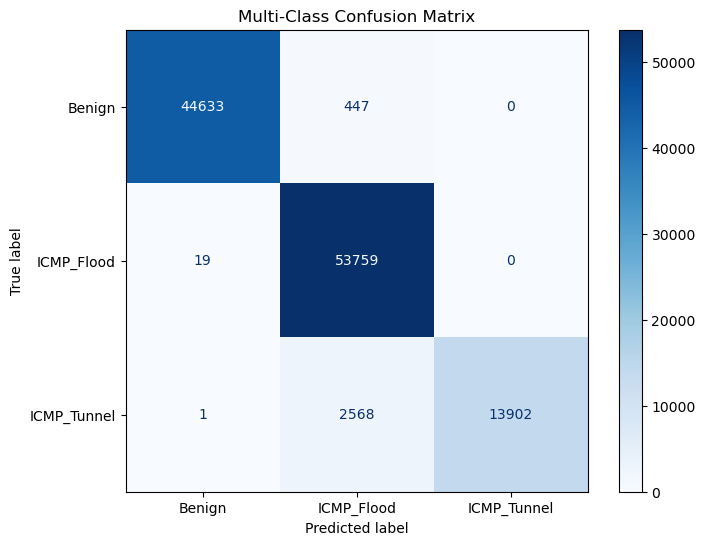

In [25]:
y_pred = model.predict(X_test)

print("── Classification Report ──────────────────────────────")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred)*100:.4f}%")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Multi-Class Confusion Matrix")
plt.grid(False)
plt.show()

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     45080
  ICMP_Flood       0.95      1.00      0.97     53778
 ICMP_Tunnel       1.00      0.84      0.92     16471

    accuracy                           0.97    115329
   macro avg       0.98      0.94      0.96    115329
weighted avg       0.98      0.97      0.97    115329

Overall Accuracy: 97.3675%


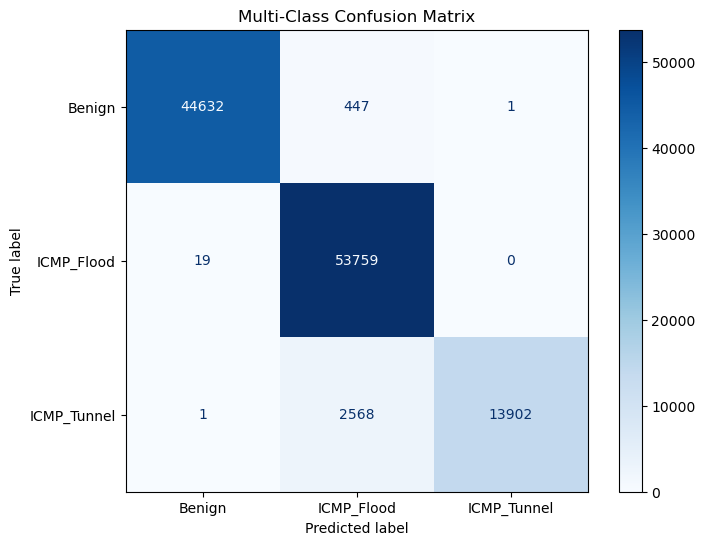

In [26]:
y_pred = model2.predict(X_test)

print("── Classification Report ──────────────────────────────")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred)*100:.4f}%")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Multi-Class Confusion Matrix")
plt.grid(False)
plt.show()

Model 2 is gave near same performance but just prediction 1 flow as ICMP tunnel when it was benign with less number of tree and shallower depth

In [27]:
IMPORTANCE_TYPE = "gain" 
TOP_N = 20                 
 
def get_importance_df(model, importance_type=IMPORTANCE_TYPE):
    """Return a tidy DataFrame of feature importances, sorted descending."""
    scores = model.get_booster().get_score(importance_type=importance_type)
    df = (
        pd.DataFrame.from_dict(scores, orient="index", columns=["importance"])
        .sort_values("importance", ascending=False)
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    df["importance_norm"] = df["importance"] / df["importance"].max()
    return df
 


In [28]:
imp1 = get_importance_df(model)
imp2 = get_importance_df(model2)
 
print(f"Model 1 – top {TOP_N} features by {IMPORTANCE_TYPE}:")
print(imp1.head(TOP_N).to_string(index=False))
print(f"\nModel 2 – top {TOP_N} features by {IMPORTANCE_TYPE}:")
print(imp2.head(TOP_N).to_string(index=False))
 

Model 1 – top 20 features by gain:
                  feature   importance  importance_norm
    bidirectional_packets 10775.666016         1.000000
        src2dst_stddev_ps 10474.197266         0.972023
      udps.fwd_header_len  1523.699829         0.141402
   udps.fwd_act_data_pkts  1138.192993         0.105626
           src2dst_max_ps   699.135315         0.064881
      src2dst_min_piat_ms   603.482300         0.056004
      bidirectional_bytes   408.712006         0.037929
              Flow Pkts/s   376.180115         0.034910
     bidirectional_max_ps   352.685669         0.032730
          src2dst_mean_ps   215.556000         0.020004
            src2dst_bytes   215.166672         0.019968
     bidirectional_min_ps   205.266785         0.019049
               Bwd Pkts/s   191.337372         0.017756
         Fwd Seg Size Avg   183.784637         0.017056
           dst2src_min_ps   177.039093         0.016430
bidirectional_duration_ms   110.919052         0.010293
          dst

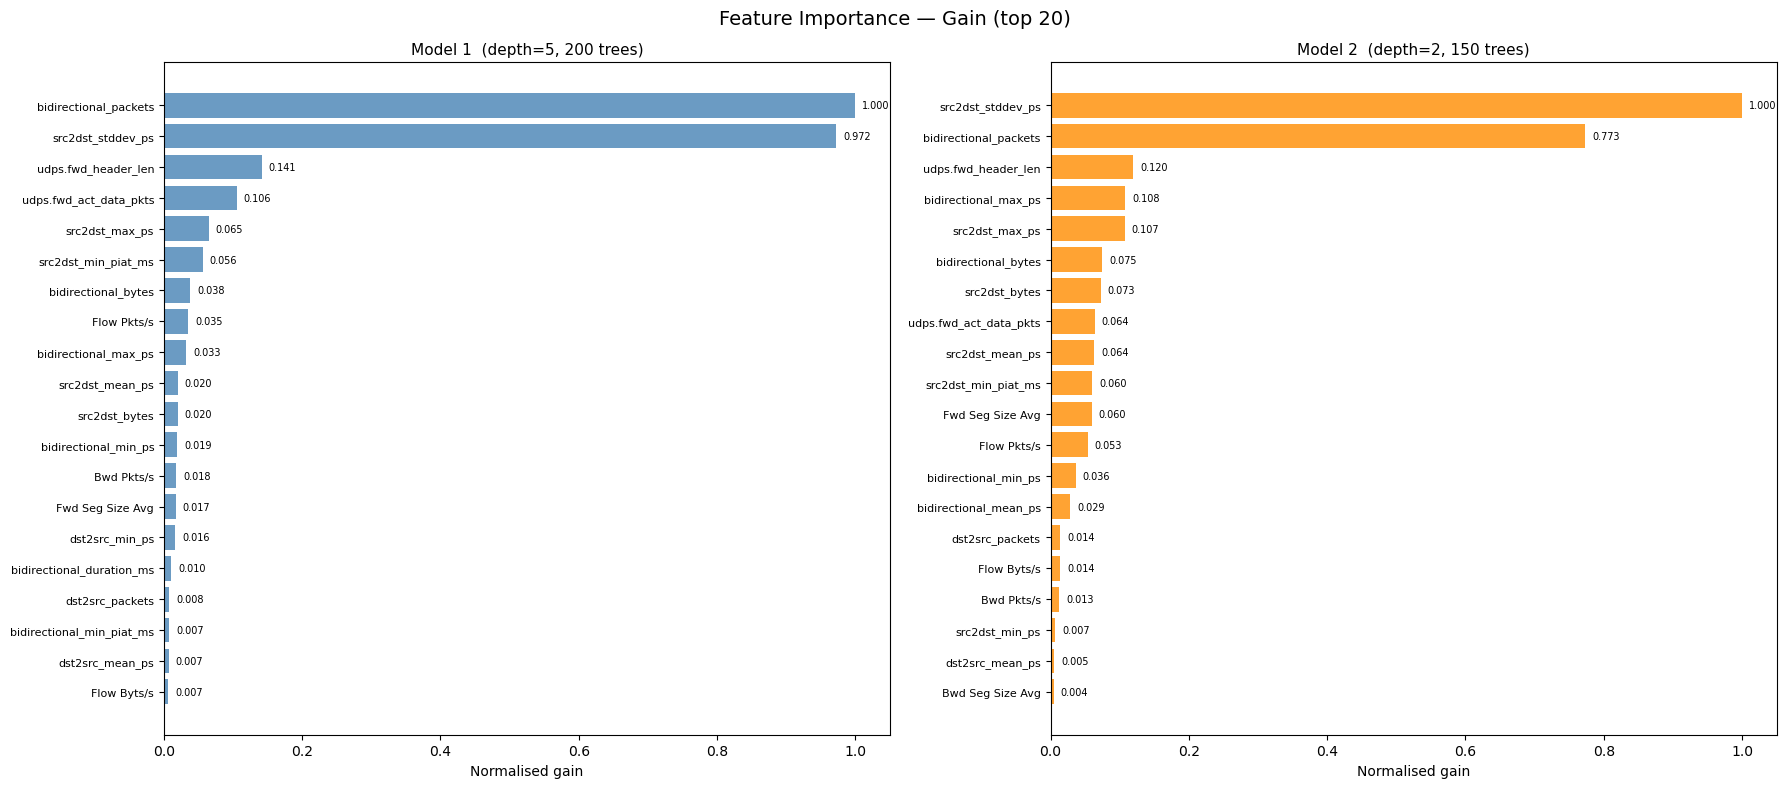

Saved → feature_importance_builtin.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f"Feature Importance — {IMPORTANCE_TYPE.capitalize()} (top {TOP_N})", fontsize=14)
 
for ax, imp, title, color in zip(
    axes,
    [imp1, imp2],
    ["Model 1  (depth=5, 200 trees)", "Model 2  (depth=2, 150 trees)"],
    ["steelblue", "darkorange"],
):
    top = imp.head(TOP_N).sort_values("importance_norm")  # ascending for barh
    ax.barh(top["feature"], top["importance_norm"], color=color, alpha=0.8)
    ax.set_xlabel(f"Normalised {IMPORTANCE_TYPE}", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 1.05)
    ax.tick_params(axis="y", labelsize=8)
    for i, (val, feat) in enumerate(zip(top["importance_norm"], top["feature"])):
        ax.text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=7)
 
plt.tight_layout()
plt.savefig("feature_importance_builtin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → feature_importance_builtin.png")

In [32]:
df_o = pd.concat([df_t, df_f], ignore_index=True)

icmp_rows = df_o[df_o['protocol'] == 1] 
print(icmp_rows[['udps.fwd_header_len', 'udps.fwd_act_data_pkts']].describe())
print("Zero fraction:", (icmp_rows[['udps.fwd_header_len', 'udps.fwd_act_data_pkts']] == 0).mean())

       udps.fwd_header_len  udps.fwd_act_data_pkts
count         5.752300e+05           575230.000000
mean          1.725624e+02                3.037571
std           6.436757e+04               22.453010
min           2.800000e+01                0.000000
25%           2.800000e+01                1.000000
50%           5.600000e+01                2.000000
75%           1.400000e+02                5.000000
max           4.881803e+07            13114.000000
Zero fraction: udps.fwd_header_len       0.000000
udps.fwd_act_data_pkts    0.116852
dtype: float64


In [33]:
joblib.dump(model2,"xgboost_model2.pkl")
joblib.dump(le,"label_encoder2.pkl")
joblib.dump(X_train.columns.tolist(),"feature_columns2.pkl")

print("Saved. Verifying round-trip...")

m   = joblib.load("xgboost_model2.pkl")
enc = joblib.load("label_encoder2.pkl")
fc  = joblib.load("feature_columns2.pkl")

assert list(enc.classes_) == list(le.classes_), "Label encoder mismatch"
assert fc == X_train.columns.tolist(),"Feature columns mismatch"
assert m.n_features_in_ == len(fc),"Feature count mismatch"
print(f"OK — {len(fc)} features, classes: {list(enc.classes_)}")

Saved. Verifying round-trip...
OK — 71 features, classes: ['Benign', 'ICMP_Flood', 'ICMP_Tunnel']
